# CAR PRICE PREDICTION WITH MACHINE LEARNING

## About Dataset

The price of a car depends on a variety of factors such as:

- The brand goodwill
- Features and specifications
- Horsepower
- Mileage
- Fuel type
- Transmission type
- Ownership history
- And more

Car price prediction is a major area of research in the field of machine learning. This dataset provides several attributes related to car features that can be used to train a model to predict the selling price of cars.

### Dataset Features

| Feature Name     | Description                            |
|------------------|----------------------------------------|
| `Car_Name`       | Name of the car                        |
| `Year`           | Year of manufacture                    |
| `Selling_Price`  | Price at which the car is being sold   |
| `Present_Price`  | Current ex-showroom price of the car   |
| `Driven_kms`     | Number of kilometers the car has been driven |
| `Fuel_Type`      | Type of fuel used (e.g., Petrol, Diesel) |
| `Selling_type`   | Type of sale (e.g., Dealer, Individual)|
| `Transmission`   | Transmission type (Manual/Automatic)   |
| `Owner`          | Number of previous owners              |

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Description

In [2]:
df = pd.read_csv('car data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [4]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [5]:
df.describe(include='object')

,Car_Name,Fuel_Type,Selling_type,Transmission
count,301,301,301,301
unique,98,3,2,2
top,city,Petrol,Dealer,Manual
freq,26,239,195,261


In [6]:
numeric_features = df.select_dtypes(include='number').columns
numeric_features

Index(['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Owner'], dtype='object')

In [7]:
categorical_features = df.select_dtypes(include='object').columns
categorical_features

Index(['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission'], dtype='object')

In [8]:
for col in categorical_features:
    print(df[col].value_counts())
    print('-'*30)

Car_Name
city                        26
corolla altis               16
verna                       14
fortuner                    11
brio                        10
                            ..
Honda CB Trigger             1
Yamaha FZ S                  1
Bajaj Pulsar 135 LS          1
Activa 4g                    1
Bajaj Avenger Street 220     1
Name: count, Length: 98, dtype: int64
------------------------------
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
------------------------------
Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64
------------------------------
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64
------------------------------


## Data Preprocessing

### 1. Check **Duplicates**

In [9]:
df.duplicated().sum()

2

#### Remove **Duplicates**

In [10]:
df.drop_duplicates(inplace=True)

### Check **Missing Values**

In [11]:
df.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

### Check Outliers

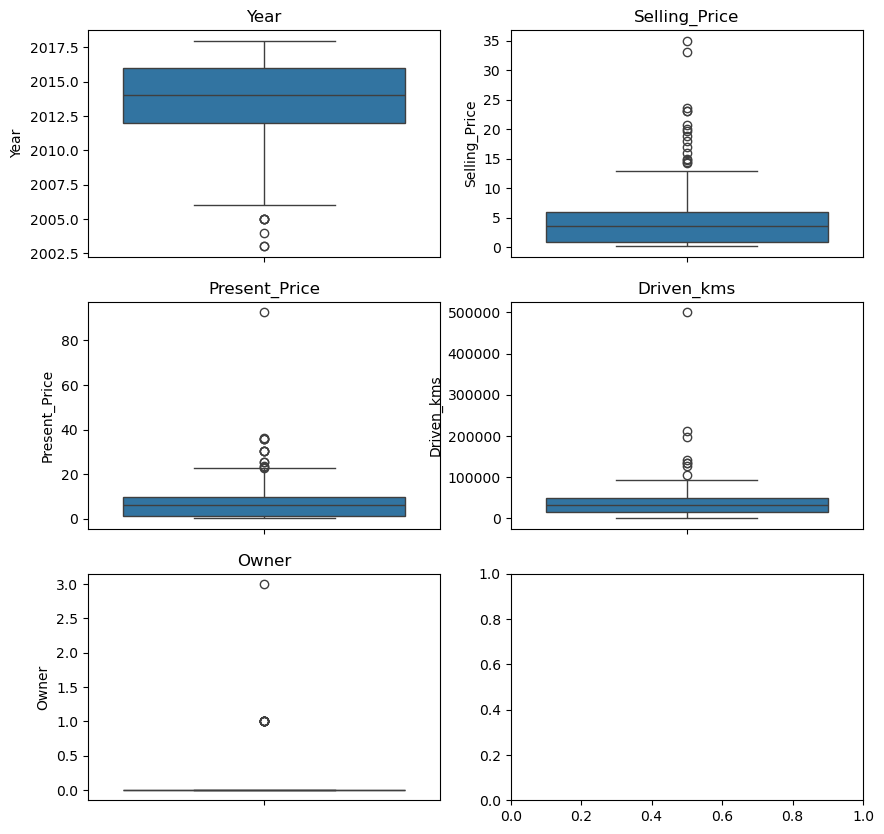

In [12]:
fig, axes = plt.subplots(nrows=3, ncols=2 , figsize=(10, 10))
axes = axes.ravel()

for i, col in enumerate(numeric_features):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(col)

#### Handle Outliers

In [13]:
df[df['Present_Price'] > 50]

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
86,land cruiser,2010,35.0,92.6,78000,Diesel,Dealer,Manual,0


In [14]:
df = df[df['Present_Price'] <= 50]

In [15]:
df[df['Driven_kms'] > 250000]

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
196,Activa 3g,2008,0.17,0.52,500000,Petrol,Individual,Automatic,0


In [16]:
df = df[df['Driven_kms'] <= 250000]

In [17]:
df[df['Owner'] == 3]

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
85,camry,2006,2.5,23.73,142000,Petrol,Individual,Automatic,3


In [18]:
df = df[df['Owner'] != 3]

## Exploratory Data Analysis (EDA)

In [19]:
df.sample(1)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
281,city,2006,2.1,7.6,50456,Petrol,Dealer,Manual,0


In [20]:
# manually adding annotations to each bar
def annotate_bars(ax):
    for p in ax.patches:
        count = int(p.get_height())
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.text(x, y, str(count), ha='center', va='bottom')

In [21]:
df['Car_Name'].nunique()

96

### Top 10 brands

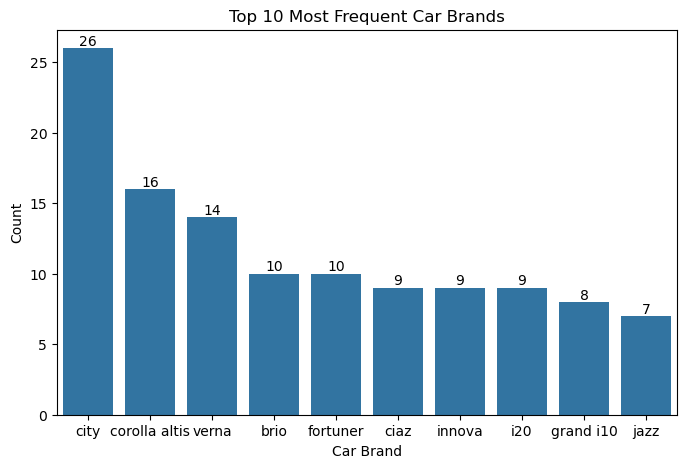

In [22]:
brand_counts = df['Car_Name'].value_counts()
top_10 = brand_counts[0 : 10]

plt.figure(figsize=(8,5))
ax = sns.barplot(x=top_10.index, y=top_10.values)
plt.title('Top 10 Most Frequent Car Brands')
plt.xlabel('Car Brand')
plt.ylabel('Count')

annotate_bars(ax)

#### This figure show that **City** is most frequent car brand exist

### Year Distribution

Text(0, 0.5, 'Counts')

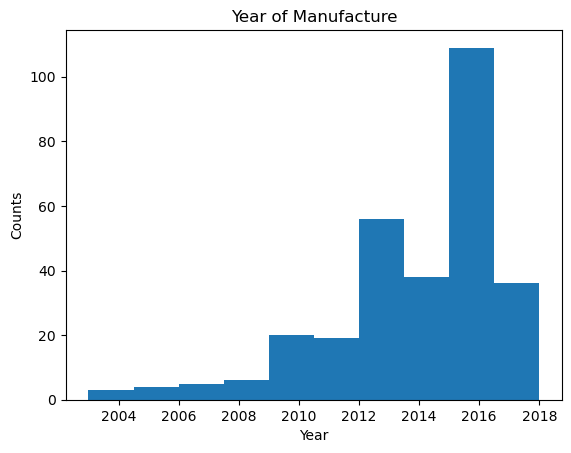

In [23]:
plt.hist(df['Year'])
plt.title('Year of Manufacture')
plt.xlabel('Year')
plt.ylabel('Counts')

#### This figure show that **2016** is the most manufacture year exist

In [24]:
top_10_names = top_10.index.tolist()
top_10_df = df[df['Car_Name'].isin(top_10_names)]

### Average Driven kms by Brand

Text(0, 0.5, 'Number of kilometers')

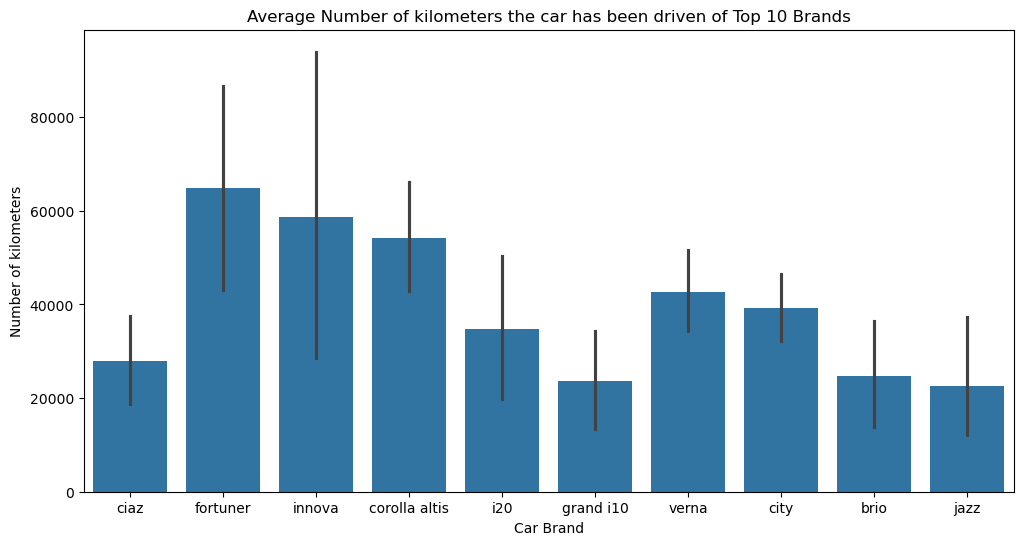

In [25]:
plt.figure(figsize=(12,6))
sns.barplot(data=top_10_df, x='Car_Name', y='Driven_kms', estimator='mean')
plt.title('Average Number of kilometers the car has been driven of Top 10 Brands')
plt.xlabel('Car Brand')
plt.ylabel('Number of kilometers')

### Average Selling Price by Brand

Text(0, 0.5, 'Selling Price')

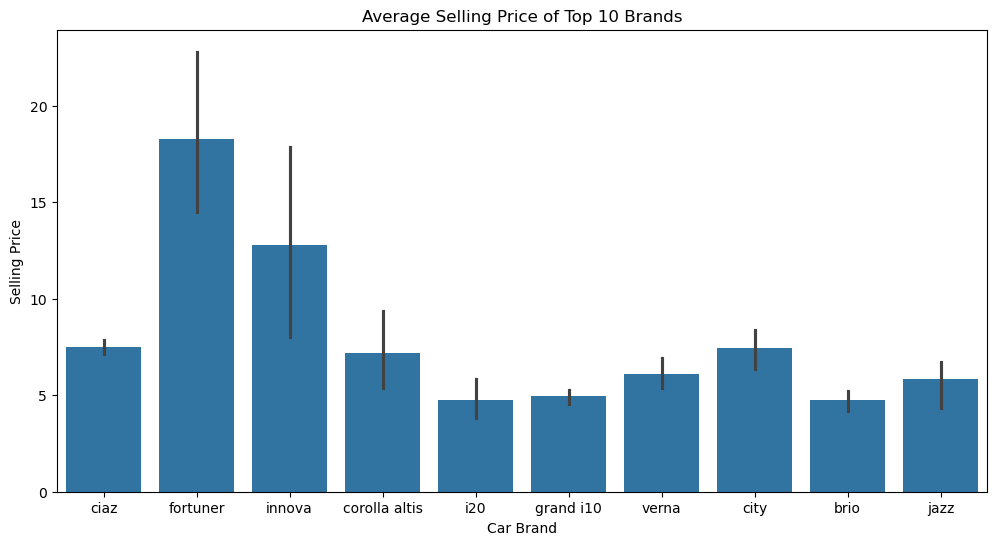

In [26]:
plt.figure(figsize=(12,6))
sns.barplot(data=top_10_df, x='Car_Name', y='Selling_Price', estimator='mean')
plt.title('Average Selling Price of Top 10 Brands')
plt.xlabel('Car Brand')
plt.ylabel('Selling Price')

### Present Selling Price by Brand

Text(0, 0.5, 'Present Price')

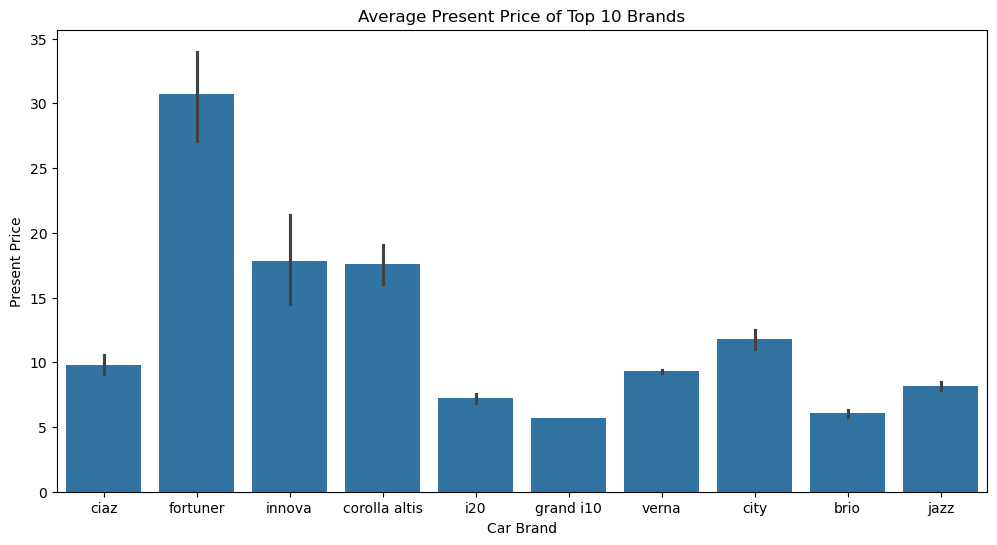

In [27]:
plt.figure(figsize=(12,6))
sns.barplot(data=top_10_df, x='Car_Name', y='Present_Price', estimator='mean')
plt.title('Average Present Price of Top 10 Brands')
plt.xlabel('Car Brand')
plt.ylabel('Present Price')

#### These 2 figures show that **Fortuner** is the most expensive car brand exist
#### and most car has Average Number of kilometers the car has been driven

### Brand vs. Fuel Type

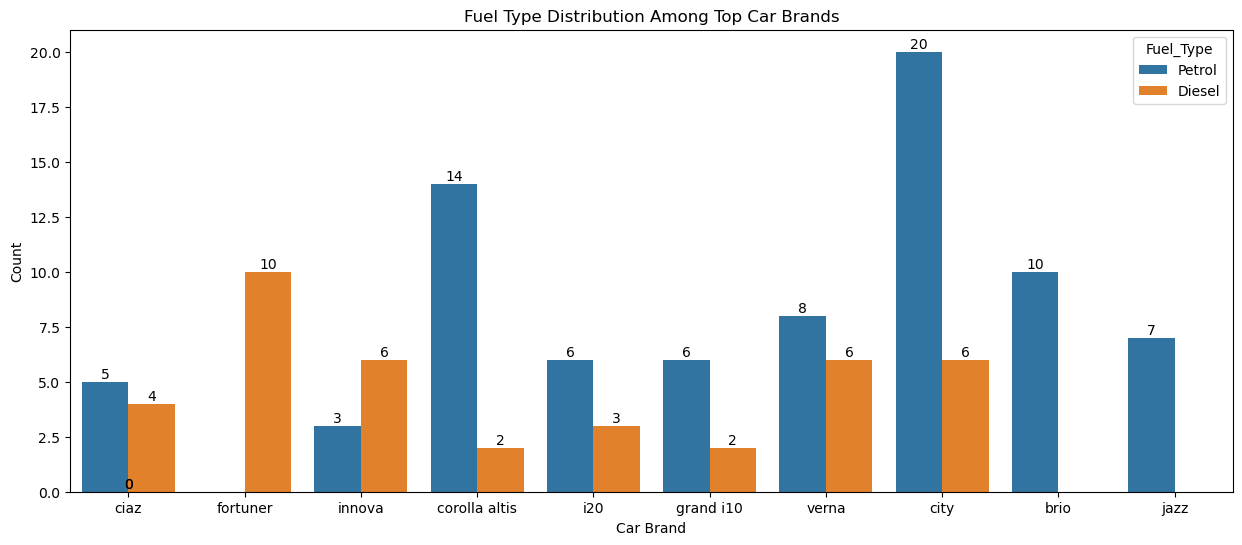

In [28]:
plt.figure(figsize=(15,6))
ax = sns.countplot(data=top_10_df, x='Car_Name', hue='Fuel_Type')
plt.title('Fuel Type Distribution Among Top Car Brands')
plt.xlabel('Car Brand')
plt.ylabel('Count')

annotate_bars(ax)

#### This figure show that **Petrol** is more popular than Diesel. 

### Brand vs. Transmission Type

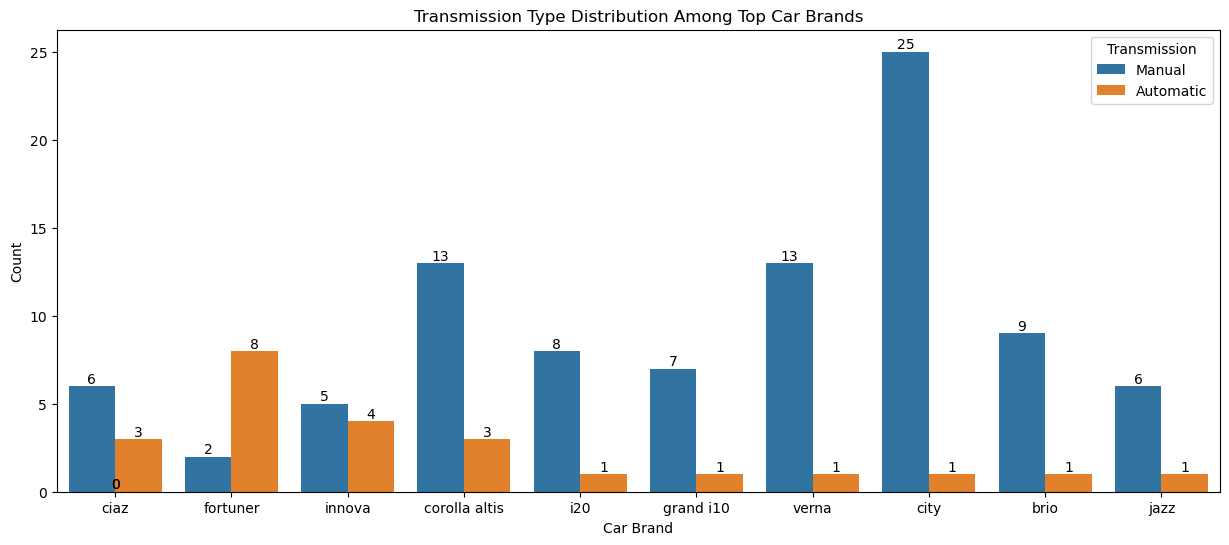

In [29]:
plt.figure(figsize=(15,6))
ax = sns.countplot(data=top_10_df, x='Car_Name', hue='Transmission')
plt.title('Transmission Type Distribution Among Top Car Brands')
plt.xlabel('Car Brand')
plt.ylabel('Count')

annotate_bars(ax)

#### This figure show that **Manual** is more popular than Automatic. 

### Owner Distribution

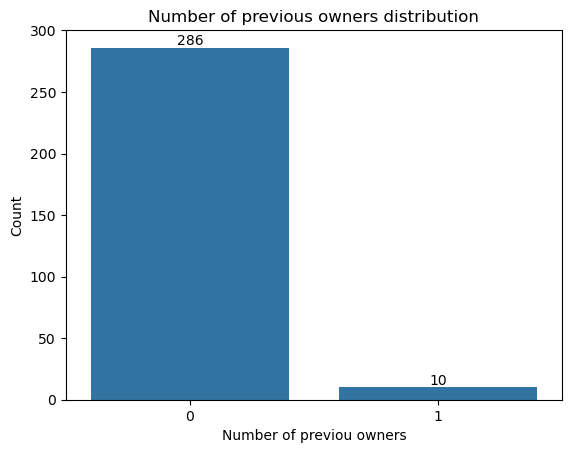

In [30]:
ax = sns.countplot(data=df, x='Owner')
plt.title('Number of previous owners distribution')
plt.xlabel('Number of previou owners')
plt.ylabel('Count')

annotate_bars(ax)

#### This figure show that most of cars **don't have any Previous Owner**

### Selling_type Distribution

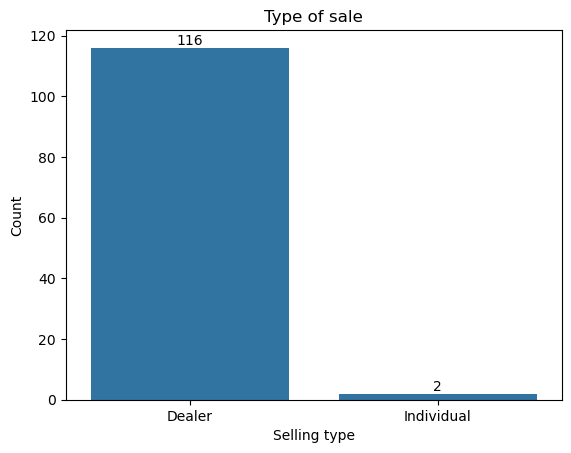

In [31]:
ax = sns.countplot(data=top_10_df, x='Selling_type')
plt.title('Type of sale')
plt.xlabel('Selling type')
plt.ylabel('Count')

annotate_bars(ax)

#### This figure show that most of Selling type is **Dealer**

### Relation between Present Price & Selling Price

Text(0, 0.5, 'Selling Price')

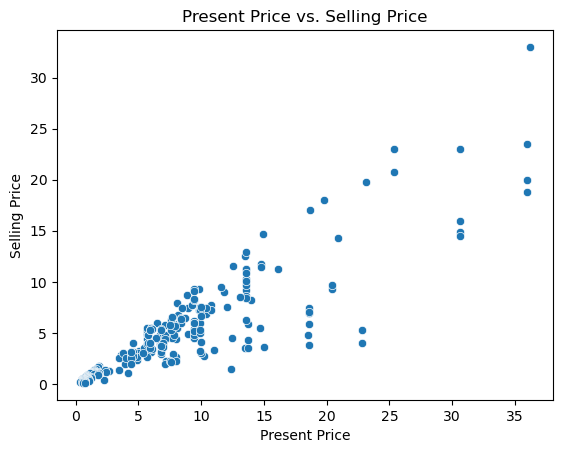

In [32]:
sns.scatterplot(data=df, x='Present_Price', y='Selling_Price')
plt.title('Present Price vs. Selling Price')
plt.xlabel('Present Price')
plt.ylabel('Selling Price')

#### This figure show that they have **Positive Linear** relationship

### Correlation

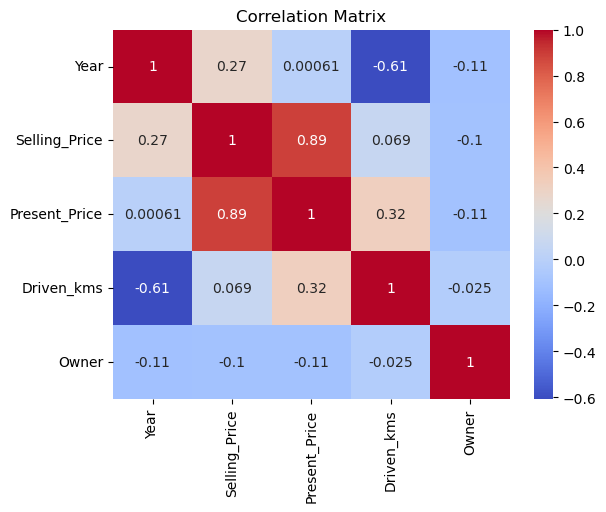

In [33]:
sns.heatmap(df[numeric_features].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Feature Engineering

In [34]:
df1 = df.copy()

### Feature Selection

#### Drop **Driven_kms** because it has low correlation to **Selling_Price** is **Less than 0.1**

In [35]:
df1.drop(columns='Driven_kms', inplace=True)

### Data Splitting

#### Split data to **80%** Training and **20%** Testing

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X = df1.drop(columns='Selling_Price')
y = df1['Selling_Price']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Data Encoding

#### Convert **Categorical Columns** to **Numeric/Binary**

In [39]:
from sklearn.preprocessing import LabelEncoder

In [40]:
le = LabelEncoder()
X_train['Fuel_Type'] = le.fit_transform(X_train['Fuel_Type'])
X_test['Fuel_Type'] = le.transform(X_test['Fuel_Type'])

X_train['Transmission'] = le.fit_transform(X_train['Transmission'])
X_test['Transmission'] = le.transform(X_test['Transmission'])

X_train['Selling_type'] = le.fit_transform(X_train['Selling_type'])
X_test['Selling_type'] = le.transform(X_test['Selling_type'])

In [41]:
# Combine train and test temporarily
combined = pd.concat([X_train, X_test], axis=0)

# Fit on full data
combined['Car_Name'] = le.fit_transform(combined['Car_Name'])

# Split again
X_train['Car_Name'] = combined['Car_Name'][:len(X_train)]
X_test['Car_Name'] = combined['Car_Name'][len(X_train):]

### Data Scalling

#### Make sure that features in same or close **Range**

In [42]:
from sklearn.preprocessing import StandardScaler

In [43]:
SS = StandardScaler()

X_train_S = SS.fit_transform(X_train)
X_test_S = SS.transform(X_test)

## Modelling (Linear Regression)

### Model Training

In [44]:
from sklearn.linear_model import LinearRegression

In [45]:
model = LinearRegression()
model.fit(X_train_S, y_train)

LinearRegression()

### Model Evaluation

In [46]:
from sklearn.metrics import classification_report, r2_score, mean_squared_error

In [47]:
y_pred = model.predict(X_test_S)

In [48]:
y_test[:5], y_pred[:5]

(279     6.25
 159     0.45
 87      5.90
 83     12.50
 266     3.65
 Name: Selling_Price, dtype: float64,
 array([8.00177795, 2.32755119, 7.21778718, 9.16028745, 4.32328321]))

In [49]:
print("R² Score:", round(r2_score(y_test, y_pred), 2))
print("MSE:", round(mean_squared_error(y_test, y_pred),2))

R² Score: 0.83
MSE: 3.11


#### This means **Linear Regression** model **explains 83%** of the **variance** in the car prices

## Modelling (KNN)

### Model Training

In [50]:
from sklearn.neighbors import KNeighborsRegressor

In [51]:
model = KNeighborsRegressor()
model.fit(X_train_S, y_train)

KNeighborsRegressor()

### Model Evaluation

In [52]:
y_pred = model.predict(X_test_S)

In [53]:
y_test[:5], y_pred[:5]

(279     6.25
 159     0.45
 87      5.90
 83     12.50
 266     3.65
 Name: Selling_Price, dtype: float64,
 array([8.73 , 0.406, 4.84 , 9.85 , 4.47 ]))

In [54]:
print("R² Score:", round(r2_score(y_test, y_pred), 2))
print("MSE:", round(mean_squared_error(y_test, y_pred),2))

R² Score: 0.91
MSE: 1.54


#### This means **KNN** model **explains 91%** of the **variance** in the car prices

## Modelling (Random Forest)

### Model Training

In [55]:
from sklearn.ensemble import RandomForestRegressor

In [56]:
model = RandomForestRegressor()
model.fit(X_train_S, y_train)

RandomForestRegressor()

### Model Evaluation

In [57]:
y_pred = model.predict(X_test_S)

In [58]:
y_test[:5], y_pred[:5]

(279     6.25
 159     0.45
 87      5.90
 83     12.50
 266     3.65
 Name: Selling_Price, dtype: float64,
 array([ 7.7662129 ,  0.4557    ,  5.21888095, 10.46844167,  4.0095    ]))

In [59]:
print("R² Score:", round(r2_score(y_test, y_pred), 2))
print("MSE:", round(mean_squared_error(y_test, y_pred),2))

R² Score: 0.96
MSE: 0.78


#### This means **Random Forest** model **explains 96%** of the **variance** in the car prices

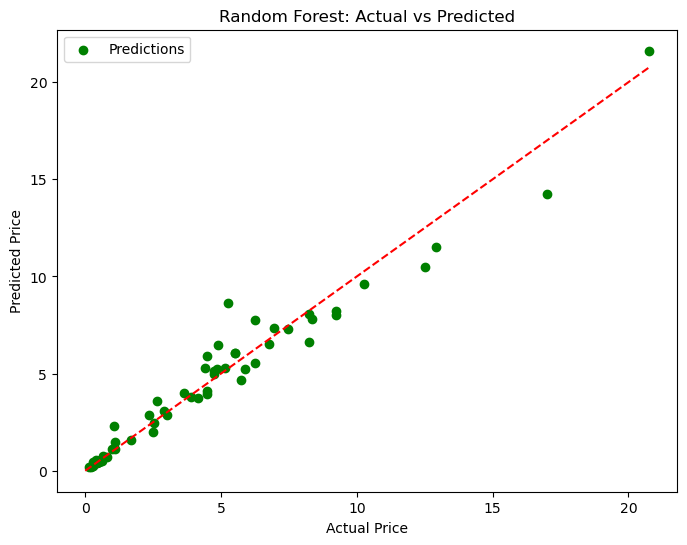

In [60]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='green', label='Predictions')
plt.plot([0, max(y_test)], [0, max(y_test)], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest: Actual vs Predicted')
plt.legend()

### Hyperparameters Tuning

#### RandomForestRegressor – Hyperparameter Tuning Notes

| Hyperparameter         | Type        | Description                                                                 | Recommended Values                | Notes                                                                                   |
|------------------------|-------------|-----------------------------------------------------------------------------|-----------------------------------|-----------------------------------------------------------------------------------------|
| `n_estimators`         | int         | Number of trees in the forest                                               | 100, 200, 300, 500                | More trees generally improve performance but increase training time.                    |
| `max_depth`            | int or None | Maximum depth of each decision tree                                        | None, 10, 20, 30, 50              | Use `None` to expand nodes until all leaves are pure. Controls overfitting.             |
| `min_samples_split`    | int or float| Minimum number of samples to split an internal node                        | 2, 5, 10                          | Higher values reduce overfitting but may underfit.                                      |
| `min_samples_leaf`     | int or float| Minimum number of samples at a leaf node                                   | 1, 2, 4                           | Useful to control overfitting and make trees more general.                              |
| `max_features`         | str or int  | Number of features to consider at each split                               | 'auto', 'sqrt', 'log2'           | `'auto'` = all features for regression; `'sqrt'`/`'log2'` may help reduce overfitting.  |
| `bootstrap`            | bool        | Whether bootstrap samples are used when building trees                     | True, False                      | `True` gives better variance control; `False` trains on full dataset (less variance).   |
| `oob_score`            | bool        | Whether to use out-of-bag samples to estimate generalization error         | True, False                      | Only relevant if `bootstrap=True`; helpful for internal validation.                     |
| `n_jobs`               | int         | Number of jobs to run in parallel                                          | -1 (all cores), 1                | Use `-1` to speed up training with multi-core processors.                               |
| `random_state`         | int         | Seed for random number generation                                          | Any integer                      | Ensures reproducibility.                                                                |
| `max_samples`          | int or float| Number or fraction of samples to train each base estimator (with bootstrap)| Default = None                   | Only used if `bootstrap=True`. Controls sample size for each tree.                      |


In [61]:
from sklearn.model_selection import GridSearchCV

In [62]:
# Define the model
rf = RandomForestRegressor(random_state=42)

In [63]:
# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

In [64]:
# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=2,
    n_jobs=-1
)

In [65]:
# Fit the model
grid_search.fit(X_train_S, y_train)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_mean_squared_error', verbose=2)

In [66]:
# Best model
best_model = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

Best parameters: {'bootstrap': False, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [67]:
# Evaluate on test set
y_pred = best_model.predict(X_test_S)

In [68]:
y_test[:5], y_pred[:5]

(279     6.25
 159     0.45
 87      5.90
 83     12.50
 266     3.65
 Name: Selling_Price, dtype: float64,
 array([6.77992374, 0.47609861, 4.87656137, 8.33800697, 4.03820627]))

In [69]:
print("R² Score:", round(r2_score(y_test, y_pred), 2))
print("MSE:", round(mean_squared_error(y_test, y_pred),2))

R² Score: 0.94
MSE: 1.0


### Model Saving

#### Since **Random Forest** is best model, so will save it for Deployment

In [70]:
import joblib
joblib.dump(model, 'car_price_model.pkl')

['car_price_model.pkl']